# 🎓 Configuración del Entorno y Fundamentos

**Fundamentos de Visión Artificial con Python y OpenCV**. 

### 🎯 Objetivos de Aprendizaje
Al finalizar esta práctica, serás capaz de:
1.  Comprender cómo una computadora "ve" una imagen (Matrices y NumPy).
2.  Cargar, visualizar y guardar imágenes usando OpenCV.
3.  Manipular propiedades básicas de los píxeles.
4.  Capturar video en tiempo real desde tu webcam.

---

## 1. Introducción Teórica

### 1.1 ¿Qué es la Visión Artificial?
Es la disciplina que busca enseñar a las computadoras a "ver" y entender el mundo visual, tal como lo hacemos los humanos. 

**Ejemplos cotidianos:**
* 📱 Desbloqueo facial en smartphones
* 🚗 Cámaras de reversa y conducción autónoma
* 🏥 Detección de tumores en rayos X

### 1.2 ¿Cómo representa la computadora una imagen?
Para una computadora, una imagen no es más que una **matriz de números**.

* **Escala de Grises:** Matriz 2D (Alto × Ancho). Cada celda (píxel) va de 0 (Negro) a 255 (Blanco).
* **Color (RGB/BGR):** Matriz 3D (Alto × Ancho × 3 canales).

⚠️ **Nota Importante:** OpenCV carga las imágenes por defecto en formato **BGR** (Blue, Green, Red), a diferencia del estándar **RGB** que usan la mayoría de las otras librerías (como Matplotlib).

## 2. Configuración y "Hola Mundo" en OpenCV

Primero, vamos a importar las librerías necesarias y verificar que todo esté instalado correctamente.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Verificar versiones
print(f"Versión de OpenCV: {cv2.__version__}")
print(f"Versión de NumPy: {np.__version__}")

Versión de OpenCV: 4.13.0
Versión de NumPy: 2.4.2


### 2.1 Cargando tu primera imagen

Vamos a usar `cv2.imread` para cargar una imagen. 

> **Nota para Jupyter:** `cv2.imshow` abre una ventana emergente que puede bloquear el kernel en algunos sistemas operativos o en la nube. Para visualizar imágenes estáticas dentro del notebook, usaremos `matplotlib.pyplot`.

✅ Imagen cargada exitosamente
Dimensiones: Alto=192, Ancho=256, Canales=3


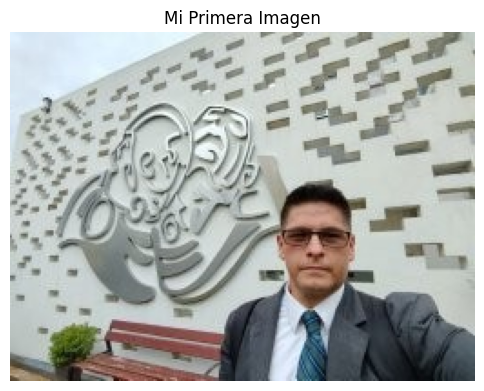

In [7]:
# 1. Cargar la imagen (Asegúrate de tener una imagen llamada 'foto.jpg' o cambia el nombre)
# Si no tienes una, puedes descargar una de prueba o usar una URL (código avanzado)
imagen = cv2.imread('foto.jpg')

# 2. Verificar si se cargó
if imagen is None:
    print("❌ Error: No se pudo cargar la imagen. Verifica la ruta del archivo.")
    # Crearemos una imagen negra de prueba para que el código no falle
    imagen = np.zeros((300, 300, 3), dtype=np.uint8)
    cv2.putText(imagen, "Imagen de Prueba", (50, 150), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
else:
    print("✅ Imagen cargada exitosamente")

# 3. Mostrar dimensiones
alto, ancho, canales = imagen.shape
print(f"Dimensiones: Alto={alto}, Ancho={ancho}, Canales={canales}")

# 4. Visualizar (Convertimos de BGR a RGB para que Matplotlib la muestre bien)
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(imagen_rgb)
plt.title("Mi Primera Imagen")
plt.axis('off') # Ocultar ejes
plt.show()

### 2.2 Manipulación de Píxeles

Como las imágenes son arrays de NumPy, podemos acceder y modificar píxeles individuales usando coordenadas `[y, x]`.

Valor del píxel en (50,50) [B, G, R]: [221 222 213]


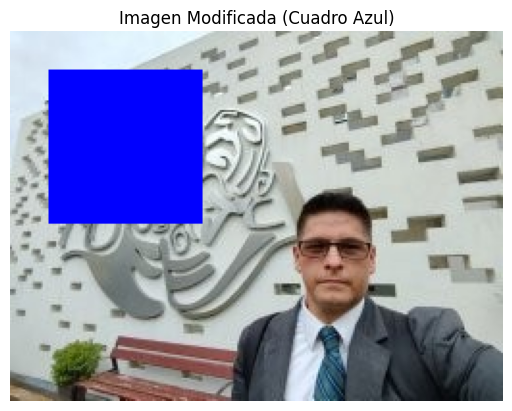

In [8]:
# Hacemos una copia para no dañar la original
img_mod = imagen.copy()

# Acceder al píxel en la posición (y=50, x=50)
pixel = img_mod[50, 50]
print(f"Valor del píxel en (50,50) [B, G, R]: {pixel}")

# Modificar una región (hacer un cuadro azul)
# Recordatorio: OpenCV es BGR -> Azul es [255, 0, 0]
img_mod[20:100, 20:100] = [255, 0, 0]

plt.imshow(cv2.cvtColor(img_mod, cv2.COLOR_BGR2RGB))
plt.title("Imagen Modificada (Cuadro Azul)")
plt.axis('off')
plt.show()

## 3. Video en Tiempo Real (Webcam)

Ahora pasaremos al video. Un video es simplemente una secuencia rápida de imágenes (frames).

**Instrucciones:**
1. El siguiente código abrirá una **ventana externa**.
2. Para cerrar la ventana y detener el código, debes presionar la tecla **'q'** en tu teclado (teniendo el foco en la ventana de video).
3. Si estás ejecutando esto en Google Colab o un servidor remoto, este bloque **no funcionará** directamente (requiere acceso local al hardware).

In [9]:
cap = cv2.VideoCapture(0) # 0 es usualmente la webcam integrada

if not cap.isOpened():
    print("❌ Error: No se puede acceder a la cámara")
else:
    print("🎥 Cámara iniciada. Presiona 'q' en la ventana emergente para salir.")
    
    while True:
        # 1. Capturar frame por frame
        ret, frame = cap.read()
        
        if not ret:
            print("No se recibió frame. Saliendo...")
            break
        
        # 2. Procesamiento (Opcional): Convertir a escala de grises
        # gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        
        # 3. Mostrar el frame resultante
        cv2.imshow('Webcam - Presiona Q para salir', frame)
        
        # 4. Control de salida
        # Espera 1ms y verifica si la tecla presionada es 'q'
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    # Liberar recursos
    cap.release()
    cv2.destroyAllWindows()
    print("✅ Transmisión finalizada.")

🎥 Cámara iniciada. Presiona 'q' en la ventana emergente para salir.
✅ Transmisión finalizada.


## 4. Ejercicios Prácticos

### 🏋️ Ejercicio 1.1: Contador de Frames
**Objetivo:** Modifica el código de la webcam para que muestre un número incremental en la pantalla (Frame 1, Frame 2, ...).

**Pista:** Usa `cv2.putText`.

In [ ]:
# Escribe tu solución aquí

cap = cv2.VideoCapture(0)
contador = 0

while True:
    ret, frame = cap.read()
    if not ret: break
    
    contador += 1
    
    # --- TU CÓDIGO AQUÍ ---
    # cv2.putText(frame, ...)
    # ----------------------
    
    cv2.imshow('Ejercicio 1', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

### 🏋️ Ejercicio 1.2: Efecto Espejo
**Objetivo:** Voltea horizontalmente el video de la webcam para que actúe como un espejo real.

**Pista:** Investiga la función `cv2.flip`.

In [ ]:
# Escribe tu solución aquí
# Tip: cv2.flip(frame, 1) realiza un volteo horizontal

## 5. 🚀 Mini-Proyecto: El Fotomatón

**Descripción:** Crea una aplicación que:
1. Muestre el video de la webcam.
2. Muestre el texto "Presiona S para foto" en pantalla.
3. Al presionar la tecla **'s'**, guarde la imagen actual en el disco como `foto_tomada.jpg`.
4. Muestre un mensaje de confirmación en la consola.

In [1]:
import cv2
import numpy as np # Importamos numpy para el efecto de flash

# Inicializar la webcam
cap = cv2.VideoCapture(0)
print("📸 Fotomatón Iniciado - Presiona 'Q' para salir")

while True:
    ret, frame = cap.read()
    if not ret: break
    
    # Hacemos una copia para mostrar en pantalla con texto/instrucciones
    # Esto mantiene el 'frame' original limpio para guardarlo
    display = frame.copy()
    
    # Dibujar instrucciones en la copia (display)
    cv2.putText(display, "Presiona 'S' para foto", (10, 30), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
    
    cv2.imshow('Fotomaton', display)
    
    # Captura de teclas (espera 1ms)
    tecla = cv2.waitKey(1) & 0xFF
    
    if tecla == ord('q'):
        break
    elif tecla == ord('s'):
        # Guardamos el 'frame' original (limpio)
        nombre_foto = "foto_tomada.jpg"
        cv2.imwrite(nombre_foto, frame)
        print(f"✅ ¡Foto guardada como {nombre_foto}!")
        
        # (Opcional) Efecto visual de 'flash' rápido
        # Mostramos una imagen blanca por 50ms
        flash = np.ones_like(frame) * 255
        cv2.imshow('Fotomaton', flash)
        cv2.waitKey(50)

# Liberar recursos siempre al final
cap.release()
cv2.destroyAllWindows()

📸 Fotomatón Iniciado - Presiona 'Q' para salir
✅ ¡Foto guardada como foto_tomada.jpg!
✅ ¡Foto guardada como foto_tomada.jpg!
✅ ¡Foto guardada como foto_tomada.jpg!
✅ ¡Foto guardada como foto_tomada.jpg!
✅ ¡Foto guardada como foto_tomada.jpg!
✅ ¡Foto guardada como foto_tomada.jpg!
✅ ¡Foto guardada como foto_tomada.jpg!
✅ ¡Foto guardada como foto_tomada.jpg!
✅ ¡Foto guardada como foto_tomada.jpg!


## 🧠 Cuestionario de Auto-Evaluación

1. **¿Qué dimensión representa los canales de color en `imagen.shape`?**
   - a) La primera (0)
   - b) La segunda (1)
   - c) La tercera (2)

2. **¿En qué orden carga OpenCV los colores por defecto?**
   - a) RGB
   - b) BGR
   - c) CMYK

3. **Si `cv2.imread` falla al cargar una imagen, ¿qué valor retorna?**
   - a) Un array de ceros
   - b) Un error de Python
   - c) `None`